**Question 1**

---

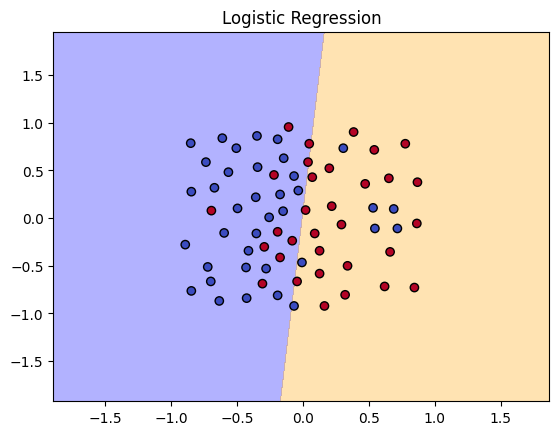

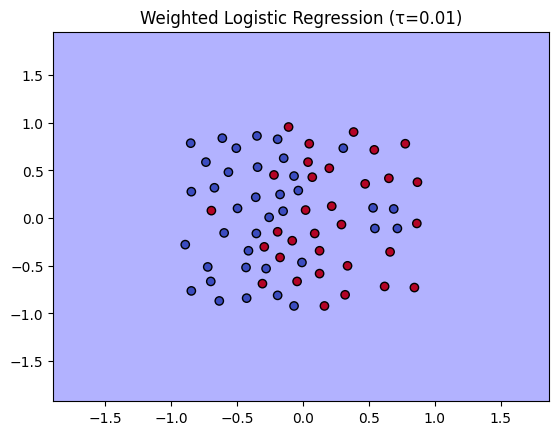

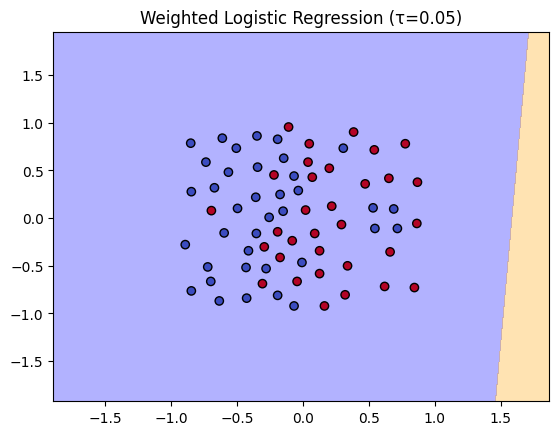

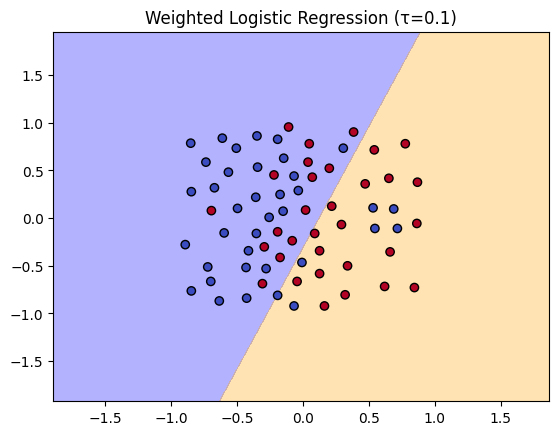

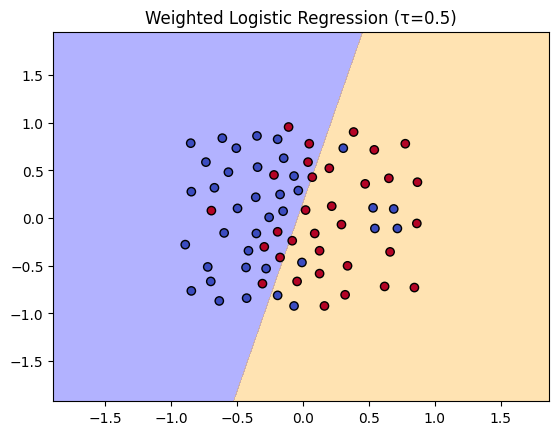

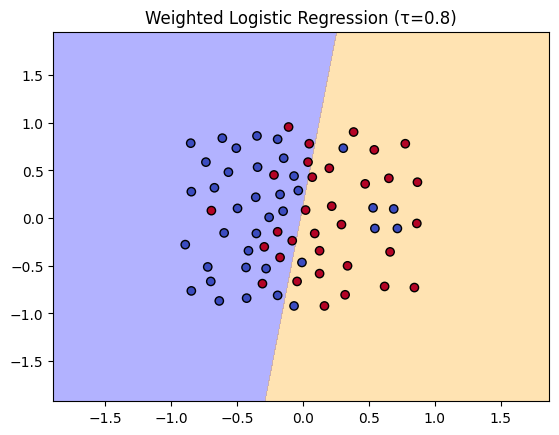

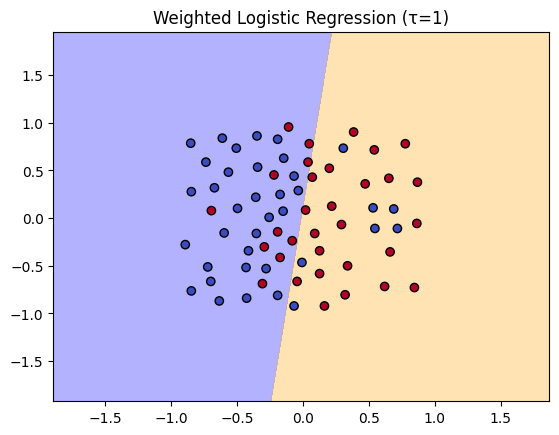

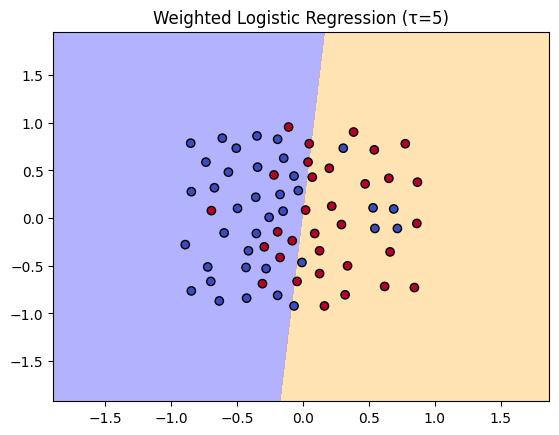

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import expit

# Sigmoid function
def sigmoid(z):
    return expit(z)

# Compute cost, gradient, and Hessian
def compute_gradient_hessian(theta, X, y, weights, lambd):
    m = len(y)
    h = sigmoid(X @ theta)

    cost = (1/m) * np.sum(weights * (-y * np.log(h) - (1 - y) * np.log(1 - h))) + (lambd/2) * np.sum(theta**2)

    gradient = (1/m) * (X.T @ (weights * (h - y))) + lambd * theta

    W = np.diag(weights * h * (1 - h))
    hessian = (1/m) * (X.T @ W @ X) + lambd * np.eye(X.shape[1])

    return cost, gradient, hessian

# Gradient descent implementation
def gradient_descent(X, y, weights, lambd, alpha=0.1, num_iters=1000):
    theta = np.zeros(X.shape[1])
    for _ in range(num_iters):
        _, gradient, _ = compute_gradient_hessian(theta, X, y, weights, lambd)
        theta -= alpha * gradient
    return theta

# Weighting function based on x0 and τ value
def compute_weights(X, x0, tau):
    return np.exp(-np.sum((X - x0) ** 2, axis=1) / (2 * tau ** 2))

# Plot decision boundary
def plot_decision_boundary(theta, X, y, title):
    xx, yy = np.meshgrid(np.linspace(X[:,1].min()-1, X[:,1].max()+1, 100),
                         np.linspace(X[:,2].min()-1, X[:,2].max()+1, 100))
    grid = np.c_[np.ones(xx.ravel().shape), xx.ravel(), yy.ravel()]
    probs = sigmoid(grid @ theta).reshape(xx.shape)

    plt.contourf(xx, yy, probs, levels=[0, 0.5, 1], alpha=0.3, colors=['blue', 'orange'])
    plt.scatter(X[:,1], X[:,2], c=y, cmap='coolwarm', edgecolors='k')
    plt.title(title)
    plt.show()

# Load data
X = np.loadtxt("/features.txt")
y = np.loadtxt("/labels.txt")
X = np.c_[np.ones(X.shape[0]), X] 

# Implement simple logistic regression
lambd = 0.0001
weights = np.ones(X.shape[0]) 

theta_simple = gradient_descent(X, y, weights, lambd)
plot_decision_boundary(theta_simple, X, y, 'Logistic Regression')

# Implement weighted logistic regression for τ=0.8
x0 = np.mean(X[:, 1:], axis=0)
tau_values = [0.01, 0.05, 0.1, 0.5, 0.8, 1, 5]

for tau in tau_values:
    weights_weighted = compute_weights(X[:, 1:], x0, tau)
    theta_weighted = gradient_descent(X, y, weights_weighted, lambd)
    plot_decision_boundary(theta_weighted, X, y, f'Weighted Logistic Regression (τ={tau})')

Predicting Cancer Tumors with Naïve Bayes Classifier

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load data
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/wdbc.data"
column_names = ['id', 'diagnosis'] + [f'feature_{i}' for i in range(1, 31)]
data = pd.read_csv(url, header=None, names=column_names)

# Preprocess data
X = data.drop(['id', 'diagnosis'], axis=1)
y = data['diagnosis'].map({'M': 1, 'B': 0})

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train Naïve Bayes model
model = GaussianNB()
model.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)

# Calculate performance metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# Address the curse of dimensionality and reduce dimensions using PCA
pca = PCA(n_components=10)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# Train model with reduced data
model_pca = GaussianNB()
model_pca.fit(X_train_pca, y_train)

# Predict on reduced test data
y_pred_pca = model_pca.predict(X_test_pca)

# Calculate performance metrics for reduced data
accuracy_pca = accuracy_score(y_test, y_pred_pca)
precision_pca = precision_score(y_test, y_pred_pca)
recall_pca = recall_score(y_test, y_pred_pca)
f1_pca = f1_score(y_test, y_pred_pca)

print("\nPerformance with PCA (10 components):")
print(f"Accuracy: {accuracy_pca:.4f}")
print(f"Precision: {precision_pca:.4f}")
print(f"Recall: {recall_pca:.4f}")
print(f"F1-Score: {f1_pca:.4f}")

Accuracy: 0.9357
Precision: 0.9194
Recall: 0.9048
F1-Score: 0.9120

Performance with PCA (10 components):
Accuracy: 0.9064
Precision: 0.8983
Recall: 0.8413
F1-Score: 0.8689


**Model Comparison on Pima Indian Diabetes Dataset**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef

# Load Pima Indian Diabetes dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
column_names = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"]
data = pd.read_csv(url, header=None, names=column_names)

# Split data into features (X) and labels (y)
X = data.drop(columns=["Outcome"])
y = data["Outcome"]

# Handle missing values using SimpleImputer
imputer = SimpleImputer(strategy="mean")
X = imputer.fit_transform(X)

# Normalize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Define models
models = {
    "Logistic Regression": LogisticRegression(),
    "Support Vector Machine": SVC(),
    "XGBoost": XGBClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Naive Bayes": GaussianNB()
}

# Train and evaluate models
results = {}
for name, model in models.items():
    # Train the model
    model.fit(X_train, y_train)

    # Predict on test data
    y_pred = model.predict(X_test)

    # Calculate performance metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    mcc = matthews_corrcoef(y_test, y_pred)

    # Save results
    results[name] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "MCC": mcc
    }

# Display results
for model_name, metrics in results.items():
    print(f"\n{model_name}:")
    for metric_name, value in metrics.items():
        print(f"{metric_name}: {value:.4f}")

# Custom implementation of evaluation metrics
def accuracy(y_true, y_pred):
    return np.sum(y_true == y_pred) / len(y_true)

def precision(y_true, y_pred):
    true_positives = np.sum((y_true == 1) & (y_pred == 1))
    predicted_positives = np.sum(y_pred == 1)
    return true_positives / predicted_positives

def recall(y_true, y_pred):
    true_positives = np.sum((y_true == 1) & (y_pred == 1))
    actual_positives = np.sum(y_true == 1)
    return true_positives / actual_positives

def f1_score(y_true, y_pred):
    p = precision(y_true, y_pred)
    r = recall(y_true, y_pred)
    return 2 * (p * r) / (p + r)

def mcc(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    numerator = tp * tn - fp * fn
    denominator = np.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))
    return numerator / denominator


Logistic Regression:
Accuracy: 0.7359
Precision: 0.6173
Recall: 0.6250
F1-Score: 0.6211
MCC: 0.4185

Support Vector Machine:
Accuracy: 0.7489
Precision: 0.6486
Recall: 0.6000
F1-Score: 0.6234
MCC: 0.4362

XGBoost:
Accuracy: 0.7273
Precision: 0.5977
Recall: 0.6500
F1-Score: 0.6228
MCC: 0.4107

Decision Tree:
Accuracy: 0.7186
Precision: 0.5728
Recall: 0.7375
F1-Score: 0.6448
MCC: 0.4270

Naive Bayes:
Accuracy: 0.7446
Precision: 0.6235
Recall: 0.6625
F1-Score: 0.6424
MCC: 0.4445


**Exploring SVM Parameters for Classification**   سوال4

---







Exploring SVM Parameters for Classification سوال4

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Load Pima Indian Diabetes dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
column_names = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"]
data = pd.read_csv(url, header=None, names=column_names)

# Split data into features (X) and labels (y)
X = data.drop(columns=["Outcome"])
y = data["Outcome"]

# Handle missing values using SimpleImputer
imputer = SimpleImputer(strategy="mean")
X = imputer.fit_transform(X)

# Normalize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Define SVM model
svm_model = SVC()

# Train the model on training data
svm_model.fit(X_train, y_train)

# Predict on test data
y_pred = svm_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Initial SVM Results (Default Parameters):")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

Initial SVM Results (Default Parameters):
Accuracy: 0.7489
Precision: 0.6486
Recall: 0.6000
F1-Score: 0.6234


"**Experimenting with SVM Parameters
** Changing Kernel"

In [ ]:
kernels = ["linear", "poly", "rbf", "sigmoid"]
for kernel in kernels:
    svm_model = SVC(kernel=kernel)
    svm_model.fit(X_train, y_train)
    y_pred = svm_model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"\nKernel: {kernel}")
    print(f"Accuracy: {accuracy:.4f}")


Kernel: linear
Accuracy: 0.7489

Kernel: poly
Accuracy: 0.7532

Kernel: rbf
Accuracy: 0.7489

Kernel: sigmoid
Accuracy: 0.6753


**تغییر پارامتر C**

تغییر پارامتر C

In [ ]:
c_values = [0.1, 1, 10, 100]
for c in c_values:
    svm_model = SVC(C=c, kernel="rbf")
    svm_model.fit(X_train, y_train)
    y_pred = svm_model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"\nC: {c}")
    print(f"Accuracy: {accuracy:.4f}")


C: 0.1
Accuracy: 0.7446

C: 1
Accuracy: 0.7489

C: 10
Accuracy: 0.7186

C: 100
Accuracy: 0.6970


"**Changing the Degree Parameter (for Polynomial Kernel)"

In [ ]:
degrees = [2, 3, 4, 5]
for degree in degrees:
    svm_model = SVC(kernel="poly", degree=degree)
    svm_model.fit(X_train, y_train)
    y_pred = svm_model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"\nDegree: {degree}")
    print(f"Accuracy: {accuracy:.4f}")


Degree: 2
Accuracy: 0.6840

Degree: 3
Accuracy: 0.7532

Degree: 4
Accuracy: 0.7446

Degree: 5
Accuracy: 0.7229


"**Using Grid Search to Find the Best Parameters**"

In [2]:
# Define Grid Search parameters
param_grid = {
    "kernel": ["linear", "poly", "rbf", "sigmoid"],
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", "auto"],
    "degree": [2, 3, 4, 5]
}

# Perform Grid Search
grid_search = GridSearchCV(SVC(), param_grid, cv=5, scoring="accuracy")
grid_search.fit(X_train, y_train)

# Best parameters and model
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_

print("\nBest Parameters:")
print(best_params)

# Evaluate the model with the best parameters
y_pred = best_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\nResults of the Model with Best Parameters:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")


Best Parameters:
{'C': 1, 'degree': 2, 'gamma': 'scale', 'kernel': 'linear'}

Results of the Model with Best Parameters:
Accuracy: 0.7489
Precision: 0.6410
Recall: 0.6250
F1-Score: 0.6329




------------------------------------------------------------------------------------



**Grade Prediction**

In [3]:
import numpy as np

# Coefficients of the logistic regression model
B0 = 0.3
B1 = 0.005
B2 = 0.01

# Student's features
hours_studied = 80
average_grade = 75

# Calculate the logit (linear combination)
logit = B0 + B1 * hours_studied + B2 * average_grade

# Calculate the probability using the sigmoid function
probability = 1 / (1 + np.exp(-logit))

print(f"Probability of this student scoring 100: {probability:.4f}")

Probability of this student scoring 100: 0.8100


In [4]:
# Desired probability
desired_probability = 0.90

# Student's average grade
average_grade = 60

# Calculate the desired logit for a 90% probability
desired_logit = np.log(desired_probability / (1 - desired_probability))

# Solve the equation to find the required number of study hours
hours_studied = (desired_logit - B0 - B2 * average_grade) / B1

print(f"Required study hours to achieve a 90% probability: {hours_studied:.2f} hours")

Required study hours to achieve a 90% probability: 259.44 hours
